In [2]:
%load_ext autoreload
%autoreload 2

save_plot = True


The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [3]:
# =========================================================
# CONFIG: choose which PSI to use
# =========================================================
# Options: "simple" (mean across cell lines) or "random_effects" (DerSimonian-Laird meta-analysis)
PSI_METHOD = "random_effects"  # change to "simple" to use simple mean

In [4]:
import sys
sys.path.append('..')
import pandas as pd 
import numpy as np
from pathlib import Path
import matplotlib.pyplot as plt
from results_analysis_helper import *
import json
import seaborn as sns
pd.set_option('display.max_rows', 100)

# Tell Matplotlib to export text as text, not paths (editable in Illustrator)
plt.rcParams['svg.fonttype'] = 'none'

In [5]:
gene_perf = pd.read_parquet(f"/cwork/hl489/Pertb_benchmark/DataSet2/gene_perf_combined_all_methods_detail.parquet")

In [6]:
gene_perf.head(10)

,dataset,method,split,perturbation,gene,mean_pred,mean_true,mean_pred_delta,mean_true_delta,var_pred,var_true,abs_error,squared_error,abs_error_delta,squared_error_delta,deg_rank,n_stim_cells,n_imp_cells
0,hepg2,scGPT,0,ATR,ENSG00000175054,0.140610,0.019041,-0.013433,-0.135002,0.000007,0.009097,0.121569,0.014779,0.121569,0.014779,1,100,100
1,hepg2,scGPT,0,ATR,ENSG00000276043,0.253041,0.107802,-0.105004,-0.250243,0.000063,0.063790,0.145239,0.021094,0.145239,0.021094,2,100,100
2,hepg2,scGPT,0,ATR,ENSG00000163840,0.065991,0.007228,0.006848,-0.051914,0.000002,0.002564,0.058762,0.003453,0.058762,0.003453,3,100,100
3,hepg2,scGPT,0,ATR,ENSG00000085840,0.063451,0.015063,-0.013058,-0.061445,0.000002,0.004787,0.048387,0.002341,0.048387,0.002341,4,100,100
4,hepg2,scGPT,0,ATR,ENSG00000161513,1.054180,1.605825,0.073100,0.624746,0.000197,0.573915,0.551646,0.304313,0.551646,0.304313,5,100,100
5,hepg2,scGPT,0,ATR,ENSG00000174799,0.074950,0.022072,-0.013202,-0.066081,0.000011,0.006464,0.052878,0.002796,0.052878,0.002796,6,100,100
6,hepg2,scGPT,0,ATR,ENSG00000130513,1.152422,1.809212,0.233045,0.889836,0.000256,1.313696,0.656791,0.431374,0.656791,0.431374,7,100,100
7,hepg2,scGPT,0,ATR,ENSG00000189057,0.100173,0.029557,-0.033778,-0.104394,0.000007,0.016713,0.070616,0.004987,0.070616,0.004987,8,100,100
8,hepg2,scGPT,0,ATR,ENSG00000168393,0.758384,0.568106,-0.213112,-0.403389,0.000085,0.269707,0.190277,0.036205,0.190277,0.036205,9,100,100
9,hepg2,scGPT,0,ATR,ENSG00000145365,0.059783,0.010183,0.006374,-0.043226,0.000004,0.002700,0.049600,0.002460,0.049600,0.002460,10,100,100


In [7]:
# Load split files
splits = {}
for s in range(5):
    with open(f'/cwork/hl489/perturbBench/split{s}.json') as f:
        splits[s] = json.load(f)

psi_all_deg = []
for deg in [1000, 2000, 5000]:
    gp_tm = gene_perf[(gene_perf['method'] == 'trainMean') & (gene_perf['deg_rank'] <= deg)].copy()

    rows = []
    for split_idx in range(5):
        train_perts = set(splits[split_idx]['train'])

        gp_test = gp_tm[(gp_tm['split'] == split_idx)].copy()

        other_splits = gp_tm[gp_tm['split'] != split_idx]
        train_data = other_splits[other_splits['perturbation'].isin(train_perts)]

        gene_avg = (train_data
            .groupby(['dataset', 'gene'])['mean_true_delta']
            .mean()
            .rename('avg_gene_delta')
        )

        gp_test = gp_test.merge(gene_avg, on=['dataset', 'gene'], how='left')
        gp_test['residual'] = gp_test['mean_true_delta'] - gp_test['avg_gene_delta']
        rows.append(gp_test)

    gp_all = pd.concat(rows, ignore_index=True)

    psi_deg = (gp_all
        .groupby(['dataset', 'perturbation'])
        .apply(lambda g: g['residual'].var() / g['mean_true_delta'].var() if g['mean_true_delta'].var() > 0 else np.nan,
               include_groups=False)
        .rename('PSI')
        .reset_index()
    )
    psi_deg['DEG'] = deg
    psi_all_deg.append(psi_deg)
    print(f"DEG={deg}: {len(psi_deg)} entries, {psi_deg['PSI'].notna().sum()} non-null")

psi_all_deg = pd.concat(psi_all_deg, ignore_index=True)

# Keep DEG=2000 as the default psi for the heatmap
psi = psi_all_deg[psi_all_deg['DEG'] == 2000].drop(columns='DEG').reset_index(drop=True)

DEG=1000: 1829 entries, 1829 non-null
DEG=2000: 1829 entries, 1829 non-null
DEG=5000: 1829 entries, 1829 non-null


In [8]:
# Only keep perturbations present in all 6 cell lines
n_celllines = psi.groupby('perturbation')['dataset'].nunique()
perts_all6 = n_celllines[n_celllines == 6].index

global_psi_simple = psi[psi['perturbation'].isin(perts_all6)].groupby('perturbation')['PSI'].mean().reset_index()
global_psi_simple.columns = ['perturbation', 'global_PSI']


In [9]:
global_psi_simple.sort_values('global_PSI').head(20)

,perturbation,global_PSI
117,MCM3,0.537840
96,ICE1,0.561279
65,ERCC2,0.565486
63,ELL,0.582898
166,POLR2B,0.585914
232,SUPT16H,0.589056
227,SRSF7,0.591202
116,MCM2,0.596870
187,RAD51,0.596961
214,SNAPC2,0.609252


In [10]:
# # =========================================================
# # Random-effects meta-analysis for global PSI
# # =========================================================

# def random_effects_pool(log_vals, se_vals):
#     """DerSimonian-Laird random-effects pooling of log(PSI)."""
#     y = np.asarray(log_vals, dtype=float)
#     se = np.asarray(se_vals, dtype=float)

#     m = np.isfinite(y) & np.isfinite(se) & (se > 0)
#     y, se = y[m], se[m]
#     k = len(y)
#     if k == 0:
#         return None

#     v = se**2
#     if k == 1:
#         return {'mu_log': y[0], 'se_mu_log': se[0], 'tau2': 0.0,
#                 'I2_percent': np.nan, 'k_used': 1}

#     w = 1.0 / v
#     mu_fe = np.sum(w * y) / np.sum(w)
#     Q = np.sum(w * (y - mu_fe)**2)
#     C = np.sum(w) - np.sum(w**2) / np.sum(w)
#     tau2 = max(0.0, (Q - (k - 1)) / C) if C > 0 else 0.0

#     w_re = 1.0 / (v + tau2)
#     mu = np.sum(w_re * y) / np.sum(w_re)
#     se_mu = np.sqrt(1.0 / np.sum(w_re))
#     I2 = max(0.0, (Q - (k - 1)) / Q) * 100 if Q > 0 else 0.0

#     return {'mu_log': mu, 'se_mu_log': se_mu, 'tau2': tau2,
#             'I2_percent': I2, 'k_used': k}


# def compute_psi_with_bootstrap(gene_perf, splits, max_deg=2000,
#                                 n_boot=500, random_state=0, min_boot_ok=30):
#     """Per-dataset/per-perturbation PSI with bootstrap SE (split-aware)."""
#     rng = np.random.default_rng(random_state)
#     rows = []

#     for ds in gene_perf['dataset'].dropna().unique():
#         gp_ds = gene_perf[
#             (gene_perf['dataset'] == ds) &
#             (gene_perf['method'] == 'trainMean') &
#             (gene_perf['deg_rank'] <= max_deg)
#         ]

#         for split_idx in range(5):
#             train_perts = set(splits[split_idx]['train'])
#             gp_split = gp_ds[gp_ds['split'] == split_idx]

#             # Test perturbations in this split
#             test_perts = gp_split['perturbation'].unique()

#             # Gene average from training perturbations (from other splits)
#             other = gp_ds[gp_ds['split'] != split_idx]
#             train_data = other[other['perturbation'].isin(train_perts)]
#             gene_avg = train_data.groupby('gene')['mean_true_delta'].mean()

#             for pert in test_perts:
#                 sub = gp_split[gp_split['perturbation'] == pert]
#                 genes_common = sub['gene'][sub['gene'].isin(gene_avg.index)]
#                 sub = sub[sub['gene'].isin(genes_common)]
#                 if len(sub) < 3:
#                     continue

#                 x = sub['mean_true_delta'].to_numpy(dtype=float)
#                 g = gene_avg.loc[sub['gene'].values].to_numpy(dtype=float)

#                 total_var = np.var(x, ddof=1)
#                 if not np.isfinite(total_var) or total_var <= 0:
#                     rows.append({'dataset': ds, 'split': split_idx,
#                                  'perturbation': pert, 'PSI': np.nan,
#                                  'log_PSI': np.nan, 'se_log_PSI': np.nan,
#                                  'n_genes': len(x), 'n_boot_ok': 0})
#                     continue

#                 resid_var = np.var(x - g, ddof=1)
#                 psi_val = resid_var / total_var
#                 log_psi = np.log(psi_val) if np.isfinite(psi_val) and psi_val > 0 else np.nan

#                 # Bootstrap SE for log(PSI)
#                 boot_logs = []
#                 n = len(x)
#                 for _ in range(n_boot):
#                     idx = rng.integers(0, n, size=n)
#                     xb, gb = x[idx], g[idx]
#                     vxb = np.var(xb, ddof=1)
#                     if not np.isfinite(vxb) or vxb <= 0:
#                         continue
#                     sb = np.var(xb - gb, ddof=1) / vxb
#                     if np.isfinite(sb) and sb > 0:
#                         boot_logs.append(np.log(sb))

#                 boot_logs = np.asarray(boot_logs, dtype=float)
#                 se_log = np.std(boot_logs, ddof=1) if len(boot_logs) >= min_boot_ok else np.nan

#                 rows.append({'dataset': ds, 'split': split_idx,
#                              'perturbation': pert, 'PSI': psi_val,
#                              'log_PSI': log_psi, 'se_log_PSI': se_log,
#                              'n_genes': n, 'n_boot_ok': len(boot_logs)})

#     return pd.DataFrame(rows)


# def compute_global_psi(spec_df):
#     """Random-effects pooling across datasets (and splits) per perturbation."""
#     # Average log_PSI and se across splits within each dataset first
#     ds_level = (spec_df.dropna(subset=['log_PSI', 'se_log_PSI'])
#         .groupby(['dataset', 'perturbation'])
#         .agg(log_PSI=('log_PSI', 'mean'),
#              se_log_PSI=('se_log_PSI', lambda x: np.sqrt((x**2).mean())),  # RMS of SEs
#              n_splits=('split', 'count'))
#         .reset_index()
#     )

#     out = []
#     for pert, g in ds_level.groupby('perturbation'):
#         pooled = random_effects_pool(g['log_PSI'], g['se_log_PSI'])
#         if pooled is None:
#             continue
#         mu = pooled['mu_log']
#         se_mu = pooled['se_mu_log']
#         out.append({
#             'perturbation': pert,
#             'global_PSI': np.exp(mu),
#             'ci_low_95': np.exp(mu - 1.96 * se_mu),
#             'ci_high_95': np.exp(mu + 1.96 * se_mu),
#             'k_celltypes': pooled['k_used'],
#             'tau2': pooled['tau2'],
#             'I2_percent': pooled['I2_percent']
#         })

#     return pd.DataFrame(out).sort_values('global_PSI', ascending=False)


# # =========================================================
# # Run
# # =========================================================
# print("Computing per-dataset PSI with bootstrap SEs (this may take a few minutes)...")
# spec_boot = compute_psi_with_bootstrap(gene_perf, splits, max_deg=2000, n_boot=500)
# print(f"  {len(spec_boot)} (dataset, split, perturbation) entries")

# global_psi = compute_global_psi(spec_boot)
# print(f"  {len(global_psi)} perturbations with global PSI")
# print()
# print(global_psi.describe())
# print()
# print(global_psi.sort_values('global_PSI').head(20))

In [11]:
# psi_across_celllines = global_psi[global_psi.k_celltypes == 6].reset_index(drop=True)

In [12]:
# psi_across_celllines.to_parquet("PSI_rankings.parquet", index=False)
psi_across_celllines = pd.read_parquet("PSI_rankings.parquet")

In [13]:
psi_across_celllines.sort_values("global_PSI").tail(71)

,perturbation,global_PSI,ci_low_95,ci_high_95,k_celltypes,tau2,I2_percent
70,HECTD1,1.170584,0.837658,1.635833,6,0.172912,99.005671
69,NFRKB,1.173906,0.913249,1.508959,6,0.096457,98.020599
68,KAT7,1.180218,0.957064,1.455404,6,0.066999,97.772087
67,ATF4,1.182452,0.941896,1.484445,6,0.078473,98.018441
66,BCLAF1,1.194406,0.944458,1.510503,6,0.083630,98.140412
65,TOE1,1.197700,0.912284,1.572411,6,0.113619,98.405806
64,YEATS4,1.200013,1.065983,1.350895,6,0.020463,93.970646
63,IRF2BP2,1.204396,0.930500,1.558915,6,0.101060,98.043671
62,HSP90B1,1.206351,1.036328,1.404268,6,0.031007,89.813332
61,USF2,1.207028,0.857958,1.698122,6,0.180017,98.970854


In [14]:
from scipy.stats import mannwhitneyu
from statsmodels.stats.multitest import multipletests

# Load GO annotations
go_all_df = pd.read_parquet("/cwork/hl489/perturbBench/residual_datasets/human_gene_go_annotations.parquet")

# Select PSI source based on config
if PSI_METHOD == "simple":
    psi_data = global_psi_simple.copy()
    print(f"Using SIMPLE mean PSI (n={len(psi_data)})")
else:
    psi_data = psi_across_celllines.copy()
    print(f"Using RANDOM-EFFECTS meta-analysis PSI (n={len(psi_data)})")

# Define quartiles
q25 = psi_data['global_PSI'].quantile(0.25)
q75 = psi_data['global_PSI'].quantile(0.75)

hammers = set(psi_data[psi_data['global_PSI'] <= q25]['perturbation'])
scalpels = set(psi_data[psi_data['global_PSI'] >= q75]['perturbation'])

print(f"Q25={q25:.4f}, Q75={q75:.4f}")
print(f"Hammers (bottom quartile, low PSI): {len(hammers)}")
print(f"Scalpels (top quartile, high PSI): {len(scalpels)}")

# Filter GO annotations to perturbations in our dataset
all_perts = set(psi_data['perturbation'])
go_filtered = go_all_df[
    (go_all_df["DB_Object_Symbol"].isin(all_perts)) &
    (go_all_df["Ontology"].isin(["BP", "MF", "CC"]))
]
print(f"\nGO annotations matching perturbations: {len(go_filtered)}")
print(f"Unique GO terms: {go_filtered['GO_ID'].nunique()}")

Using RANDOM-EFFECTS meta-analysis PSI (n=284)
Q25=0.7093, Q75=1.1655
Hammers (bottom quartile, low PSI): 71
Scalpels (top quartile, high PSI): 71

GO annotations matching perturbations: 8632
Unique GO terms: 2470


In [15]:
# =========================================================
# Mann-Whitney: continuous PSI vs GO term membership
# =========================================================

def go_psi_mw(avg_psi, go_df, min_genes=5):
    """Mann-Whitney: does GO term membership predict PSI?"""
    go_groups = go_df.groupby(["GO_ID", "GO_Name", "Ontology"])["DB_Object_Symbol"].apply(set)
    results = []
    for (go_id, go_name, ontology), genes in go_groups.items():
        genes_in = genes & set(avg_psi.index)
        if len(genes_in) < min_genes:
            continue
        psi_in = avg_psi.loc[list(genes_in)].values
        psi_out = avg_psi.loc[~avg_psi.index.isin(genes_in)].values
        stat, pval = mannwhitneyu(psi_in, psi_out, alternative="two-sided")
        results.append({
            "GO_ID": go_id, "GO_Name": go_name, "Ontology": ontology,
            "n_genes": len(genes_in),
            "mean_PSI_in": psi_in.mean(), "mean_PSI_out": psi_out.mean(),
            "delta": psi_in.mean() - psi_out.mean(), "pval": pval,
        })
    res = pd.DataFrame(results).sort_values("pval")
    if len(res) == 0:
        return res
    res["pval_adj"] = np.nan
    for ont, idx in res.groupby("Ontology").groups.items():
        _, padj, _, _ = multipletests(res.loc[idx, "pval"], method="fdr_bh")
        res.loc[idx, "pval_adj"] = padj
    return res

print("Functions defined.")

Functions defined.


In [16]:
# =========================================================
# 3) Mann-Whitney: continuous PSI vs GO term membership
# =========================================================
avg_psi = psi_data.set_index('perturbation')['global_PSI']

mw_psi = go_psi_mw(avg_psi, go_filtered, min_genes=5)

for ont in ["BP", "MF", "CC"]:
    sub = mw_psi[mw_psi["Ontology"] == ont]
    print(f"\n{'='*80}")
    print(f"  MW | {ont} — LOWER PSI (hammers, delta < 0)")
    print(f"{'='*80}")
    display(sub[sub["delta"] < 0].sort_values("pval").head(15))
    print(f"\n  MW | {ont} — HIGHER PSI (scalpels, delta > 0)")
    display(sub[sub["delta"] > 0].sort_values("pval").head(15))


  MW | BP — LOWER PSI (hammers, delta < 0)


,GO_ID,GO_Name,Ontology,n_genes,mean_PSI_in,mean_PSI_out,delta,pval,pval_adj
116,GO:0006397,mRNA processing,BP,44,0.818542,0.995539,-0.176997,0.000809,0.038043
111,GO:0006368,transcription elongation by RNA polymerase II,BP,16,0.734452,0.982067,-0.247615,0.001162,0.038043
92,GO:0006270,DNA replication initiation,BP,5,0.609604,0.974542,-0.364937,0.001249,0.038043
91,GO:0006260,DNA replication,BP,23,0.794867,0.983384,-0.188517,0.001268,0.038043
110,GO:0006367,transcription initiation at RNA polymerase II ...,BP,18,0.752972,0.982675,-0.229703,0.002626,0.065645
109,GO:0006366,transcription by RNA polymerase II,BP,29,0.810817,0.986006,-0.175189,0.004690,0.100498
142,GO:0008380,RNA splicing,BP,33,0.817682,0.987895,-0.170213,0.006072,0.113846
186,GO:0031124,mRNA 3'-end processing,BP,9,0.706862,0.976667,-0.269805,0.007432,0.116670
245,GO:0045945,positive regulation of transcription by RNA po...,BP,8,0.694638,0.976044,-0.281406,0.008556,0.116670
104,GO:0006351,DNA-templated transcription,BP,13,0.746523,0.978747,-0.232224,0.013185,0.140289



  MW | BP — HIGHER PSI (scalpels, delta > 0)


,GO_ID,GO_Name,Ontology,n_genes,mean_PSI_in,mean_PSI_out,delta,pval,pval_adj
175,GO:0030154,cell differentiation,BP,9,1.373652,0.954845,0.418808,0.000764,0.038043
132,GO:0007507,heart development,BP,10,1.334562,0.954743,0.379819,0.008191,0.116670
244,GO:0045944,positive regulation of transcription by RNA po...,BP,85,1.026265,0.943280,0.082985,0.012395,0.140289
257,GO:0048511,rhythmic process,BP,19,1.113199,0.957715,0.155485,0.013747,0.140289
191,GO:0031507,heterochromatin formation,BP,8,1.265361,0.959501,0.305860,0.014964,0.140289
133,GO:0007623,circadian rhythm,BP,6,1.233171,0.962396,0.270774,0.032589,0.210929
130,GO:0007399,nervous system development,BP,9,1.176507,0.961297,0.215210,0.050092,0.284025
1,GO:0000082,G1/S transition of mitotic cell cycle,BP,5,1.266684,0.962766,0.303918,0.051125,0.284025
108,GO:0006357,regulation of transcription by RNA polymerase II,BP,69,1.021753,0.950903,0.070850,0.058501,0.312118
307,GO:2000819,regulation of nucleotide-excision repair,BP,5,1.230382,0.963417,0.266966,0.060343,0.312118



  MW | MF — LOWER PSI (hammers, delta < 0)


...

,GO_ID,GO_Name,Ontology,n_genes,mean_PSI_in,mean_PSI_out,delta,pval,pval_adj
262,GO:0051213,dioxygenase activity,MF,5,1.800649,0.953197,0.847452,0.000008,0.000686
157,GO:0016491,oxidoreductase activity,MF,8,1.525755,0.951953,0.573801,0.000171,0.007505
199,GO:0032452,histone demethylase activity,MF,5,1.660528,0.955708,0.704820,0.000360,0.010548
32,GO:0000978,RNA polymerase II cis-regulatory region sequen...,MF,38,1.073661,0.951813,0.121848,0.004810,0.072829
58,GO:0003712,transcription coregulator activity,MF,16,1.189185,0.954919,0.234267,0.004966,0.072829
33,GO:0000981,"DNA-binding transcription factor activity, RNA...",MF,28,1.074897,0.956438,0.118460,0.009812,0.123347
179,GO:0030332,cyclin binding,MF,5,1.424905,0.959931,0.464975,0.019492,0.172792
41,GO:0001228,"DNA-binding transcription activator activity, ...",MF,23,1.070591,0.959086,0.111504,0.019635,0.172792
59,GO:0003713,transcription coactivator activity,MF,26,1.088157,0.956020,0.132137,0.065373,0.329888
229,GO:0043565,sequence-specific DNA binding,MF,18,1.059757,0.961915,0.097841,0.066195,0.329888



  MW | CC — LOWER PSI (hammers, delta < 0)


,GO_ID,GO_Name,Ontology,n_genes,mean_PSI_in,mean_PSI_out,delta,pval,pval_adj
77,GO:0005665,"RNA polymerase II, core complex",CC,6,0.684068,0.974247,-0.290179,0.005659,0.187300
80,GO:0005681,spliceosomal complex,CC,18,0.779678,0.980868,-0.201191,0.016239,0.187300
211,GO:0035861,site of double-strand break,CC,6,0.706682,0.973759,-0.267077,0.017300,0.187300
76,GO:0005654,nucleoplasm,CC,252,0.955741,1.065578,-0.109837,0.018536,0.187300
134,GO:0008023,transcription elongation factor complex,CC,8,0.726894,0.975109,-0.248214,0.019697,0.187300
152,GO:0016020,membrane,CC,46,0.853870,0.990198,-0.136328,0.024801,0.187300
24,GO:0000800,lateral element,CC,5,0.695708,0.972999,-0.277291,0.025474,0.187300
13,GO:0000428,DNA-directed RNA polymerase complex,CC,9,0.743506,0.975468,-0.231962,0.027628,0.187300
278,GO:0071018,U12-type catalytic step 2 spliceosome,CC,5,0.702482,0.972877,-0.270396,0.044962,0.262276
18,GO:0000781,"chromosome, telomeric region",CC,26,0.904593,0.974518,-0.069925,0.053559,0.275673



  MW | CC — HIGHER PSI (scalpels, delta > 0)


,GO_ID,GO_Name,Ontology,n_genes,mean_PSI_in,mean_PSI_out,delta,pval,pval_adj
168,GO:0017053,transcription repressor complex,CC,10,1.367407,0.953544,0.413863,0.001818,0.127281
78,GO:0005667,transcription regulator complex,CC,19,1.145611,0.955391,0.190220,0.009730,0.187300
2,GO:0000118,histone deacetylase complex,CC,5,1.303558,0.962105,0.341453,0.029433,0.187300
286,GO:0090575,RNA polymerase II transcription regulator complex,CC,18,1.049974,0.962578,0.087396,0.080441,0.314032
89,GO:0005925,focal adhesion,CC,6,1.232795,0.962404,0.270390,0.093437,0.314032
88,GO:0005886,plasma membrane,CC,13,1.120535,0.960805,0.159730,0.103463,0.314032
19,GO:0000785,chromatin,CC,73,0.989328,0.960778,0.028549,0.116641,0.314032
9,GO:0000307,cyclin-dependent protein kinase holoenzyme com...,CC,6,1.207291,0.962955,0.244336,0.161079,0.417613
72,GO:0005576,extracellular region,CC,10,1.049429,0.965149,0.084280,0.355916,0.738843
4,GO:0000123,histone acetyltransferase complex,CC,7,0.989827,0.967568,0.022259,0.366337,0.738843


In [17]:
# =========================================================
# 4) Controlled OLS + F-test: PSI ~ GO_term + depth + level + n_terms
# =========================================================
from scipy.stats import f as f_dist
from sklearn.linear_model import LinearRegression

def go_psi_controlled(avg_psi, go_df, min_genes=5):
    """OLS: does GO term membership predict PSI after controlling for depth/level/n_terms?"""
    gene_features = go_df.groupby("DB_Object_Symbol").agg(
        mean_depth=("depth", "mean"),
        mean_level=("level", "mean"),
        n_terms=("GO_ID", "count"),
    )
    gene_features = gene_features[gene_features.index.isin(avg_psi.index)]
    gene_features["psi"] = avg_psi.loc[gene_features.index].values

    go_groups = go_df.groupby(["GO_ID", "GO_Name", "Ontology"])["DB_Object_Symbol"].apply(set)

    results = []
    for (go_id, go_name, ontology), genes in go_groups.items():
        genes_in = genes & set(gene_features.index)
        if len(genes_in) < min_genes:
            continue

        gf = gene_features.copy()
        gf["has_term"] = gf.index.isin(genes_in).astype(int)

        X_full = gf[["has_term", "mean_depth", "mean_level", "n_terms"]].values
        X_null = gf[["mean_depth", "mean_level", "n_terms"]].values
        y = gf["psi"].values

        model_full = LinearRegression().fit(X_full, y)
        model_null = LinearRegression().fit(X_null, y)

        ss_res_full = ((y - model_full.predict(X_full)) ** 2).sum()
        ss_res_null = ((y - model_null.predict(X_null)) ** 2).sum()

        n = len(y)
        f_stat = (ss_res_null - ss_res_full) / (ss_res_full / (n - X_full.shape[1] - 1))
        pval = f_dist.sf(f_stat, 1, n - X_full.shape[1] - 1)

        coef = model_full.coef_[0]  # coefficient for has_term

        results.append({
            "GO_ID": go_id, "GO_Name": go_name, "Ontology": ontology,
            "n_genes": len(genes_in),
            "coef": coef,  # negative = lower PSI (hammer), positive = higher PSI (scalpel)
            "pval": pval,
        })

    res = pd.DataFrame(results).sort_values("pval")
    res["pval_adj"] = np.nan
    for ont, idx in res.groupby("Ontology").groups.items():
        _, padj, _, _ = multipletests(res.loc[idx, "pval"], method="fdr_bh")
        res.loc[idx, "pval_adj"] = padj
    return res

ctrl_psi = go_psi_controlled(avg_psi, go_filtered)

for ont in ["BP", "MF", "CC"]:
    sub = ctrl_psi[ctrl_psi["Ontology"] == ont]
    print(f"\n{'='*80}")
    print(f"  CONTROLLED | {ont} — LOWER PSI (hammers, coef < 0)")
    print(f"{'='*80}")
    display(sub[sub["coef"] < 0].sort_values("pval").head(15))
    print(f"\n  CONTROLLED | {ont} — HIGHER PSI (scalpels, coef > 0)")
    display(sub[sub["coef"] > 0].sort_values("pval").head(15))


  CONTROLLED | BP — LOWER PSI (hammers, coef < 0)


,GO_ID,GO_Name,Ontology,n_genes,coef,pval,pval_adj
116,GO:0006397,mRNA processing,BP,44,-0.163556,0.005326,0.266324
110,GO:0006367,transcription initiation at RNA polymerase II ...,BP,18,-0.217136,0.010807,0.281272
109,GO:0006366,transcription by RNA polymerase II,BP,29,-0.173545,0.012598,0.281272
91,GO:0006260,DNA replication,BP,23,-0.185571,0.014757,0.281272
142,GO:0008380,RNA splicing,BP,33,-0.158219,0.014951,0.281272
111,GO:0006368,transcription elongation by RNA polymerase II,BP,16,-0.223035,0.015494,0.281272
245,GO:0045945,positive regulation of transcription by RNA po...,BP,8,-0.301423,0.018073,0.281272
15,GO:0000724,double-strand break repair via homologous reco...,BP,12,-0.246452,0.018751,0.281272
92,GO:0006270,DNA replication initiation,BP,5,-0.348525,0.028145,0.328133
94,GO:0006281,DNA repair,BP,45,-0.133330,0.028438,0.328133



  CONTROLLED | BP — HIGHER PSI (scalpels, coef > 0)


,GO_ID,GO_Name,Ontology,n_genes,coef,pval,pval_adj
175,GO:0030154,cell differentiation,BP,9,0.409864,0.000522,0.078226
132,GO:0007507,heart development,BP,10,0.359143,0.001791,0.134288
191,GO:0031507,heterochromatin formation,BP,8,0.284125,0.023920,0.326183
133,GO:0007623,circadian rhythm,BP,6,0.276245,0.057802,0.476970
257,GO:0048511,rhythmic process,BP,19,0.143774,0.087643,0.494133
1,GO:0000082,G1/S transition of mitotic cell cycle,BP,5,0.273259,0.087899,0.494133
102,GO:0006338,chromatin remodeling,BP,45,0.099650,0.093088,0.494133
307,GO:2000819,regulation of nucleotide-excision repair,BP,5,0.265478,0.100219,0.494133
130,GO:0007399,nervous system development,BP,9,0.191375,0.106689,0.494133
108,GO:0006357,regulation of transcription by RNA polymerase II,BP,69,0.082021,0.111061,0.494133



  CONTROLLED | MF — LOWER PSI (hammers, coef < 0)


...

,GO_ID,GO_Name,Ontology,n_genes,coef,pval,pval_adj
262,GO:0051213,dioxygenase activity,MF,5,0.843188,3.956888e-08,0.000003
157,GO:0016491,oxidoreductase activity,MF,8,0.553648,7.641118e-06,0.000336
199,GO:0032452,histone demethylase activity,MF,5,0.680099,1.156850e-05,0.000339
179,GO:0030332,cyclin binding,MF,5,0.466952,3.057690e-03,0.067269
58,GO:0003712,transcription coregulator activity,MF,16,0.257952,4.007791e-03,0.070537
69,GO:0004693,cyclin-dependent protein serine/threonine kina...,MF,6,0.268328,6.415108e-02,0.624791
62,GO:0003727,single-stranded RNA binding,MF,5,0.275614,8.331255e-02,0.624791
32,GO:0000978,RNA polymerase II cis-regulatory region sequen...,MF,38,0.105039,8.799272e-02,0.624791
59,GO:0003713,transcription coactivator activity,MF,26,0.119209,1.077565e-01,0.624791
33,GO:0000981,"DNA-binding transcription factor activity, RNA...",MF,28,0.098395,1.637684e-01,0.686267



  CONTROLLED | CC — LOWER PSI (hammers, coef < 0)


,GO_ID,GO_Name,Ontology,n_genes,coef,pval,pval_adj
152,GO:0016020,membrane,CC,46,-0.159301,0.005529,0.193508
80,GO:0005681,spliceosomal complex,CC,18,-0.195019,0.021577,0.390134
79,GO:0005669,transcription factor TFIID complex,CC,11,-0.225250,0.036991,0.390134
24,GO:0000800,lateral element,CC,5,-0.321809,0.043873,0.390134
76,GO:0005654,nucleoplasm,CC,252,-0.133632,0.047314,0.390134
211,GO:0035861,site of double-strand break,CC,6,-0.275487,0.057141,0.390134
134,GO:0008023,transcription elongation factor complex,CC,8,-0.230751,0.065934,0.390134
195,GO:0031965,nuclear membrane,CC,8,-0.224400,0.072707,0.390134
276,GO:0071006,U2-type catalytic step 1 spliceosome,CC,6,-0.252847,0.077863,0.390134
278,GO:0071018,U12-type catalytic step 2 spliceosome,CC,5,-0.274062,0.080461,0.390134



  CONTROLLED | CC — HIGHER PSI (scalpels, coef > 0)


,GO_ID,GO_Name,Ontology,n_genes,coef,pval,pval_adj
168,GO:0017053,transcription repressor complex,CC,10,0.389451,0.000606,0.042404
78,GO:0005667,transcription regulator complex,CC,19,0.171901,0.041380,0.390134
2,GO:0000118,histone deacetylase complex,CC,5,0.315063,0.044903,0.390134
9,GO:0000307,cyclin-dependent protein kinase holoenzyme com...,CC,6,0.268328,0.064151,0.390134
89,GO:0005925,focal adhesion,CC,6,0.243365,0.094747,0.390134
147,GO:0010494,cytoplasmic stress granule,CC,5,0.181692,0.249771,0.588530
208,GO:0035097,histone methyltransferase complex,CC,12,0.117754,0.251808,0.588530
44,GO:0001650,fibrillar center,CC,10,0.128832,0.252227,0.588530
88,GO:0005886,plasma membrane,CC,13,0.109615,0.324090,0.687464
286,GO:0090575,RNA polymerase II transcription regulator complex,CC,18,0.074823,0.378954,0.757907


In [18]:
# =========================================================
# 5) Summary: GO terms significant in BOTH MW and Controlled (p < 0.05)
# =========================================================

# Pre-compute GO term depth/level
go_term_stats = go_filtered.groupby("GO_ID").agg(
    mean_depth=("depth", "mean"),
    mean_level=("level", "mean"),
).to_dict("index")

# Build GO_ID -> list of perturbation genes (sorted by PSI)
go_gene_groups = go_filtered[go_filtered["DB_Object_Symbol"].isin(avg_psi.index)].groupby("GO_ID")["DB_Object_Symbol"].apply(
    lambda g: sorted(set(g), key=lambda x: avg_psi.get(x, 0))
).to_dict()

mw_indexed = mw_psi.set_index("GO_ID")
ctrl_indexed = ctrl_psi.set_index("GO_ID")

merged = mw_indexed[["GO_Name", "Ontology", "n_genes", "delta", "pval", "pval_adj"]].join(
    ctrl_indexed[["coef", "pval", "pval_adj"]], lsuffix="_mw", rsuffix="_ctrl", how="inner"
)

for direction, label, sign_check in [
    ("HAMMERS (lower PSI)", "delta < 0 & coef < 0", lambda r: r["delta"] < 0 and r["coef"] < 0),
    ("SCALPELS (higher PSI)", "delta > 0 & coef > 0", lambda r: r["delta"] > 0 and r["coef"] > 0),
]:
    print(f"\n{'='*80}")
    print(f"  {direction} — GO terms with p < 0.05 in BOTH MW and Controlled")
    print(f"{'='*80}")

    for ont in ["BP", "MF", "CC"]:
        ont_sub = merged[merged["Ontology"] == ont]
        sig = ont_sub[
            ((ont_sub["pval_ctrl"] < 0.05) &
            (ont_sub["pval_mw"] < 0.05)) &
            ont_sub.apply(sign_check, axis=1)
        ].sort_values("pval_ctrl")

        print(f"\n  {ont} — {len(sig)} terms:")
        for gid, r in sig.iterrows():
            stats = go_term_stats.get(gid, {})
            depth = stats.get("mean_depth", float("nan"))
            level = stats.get("mean_level", float("nan"))
            genes = go_gene_groups.get(gid, [])
            gene_str = ", ".join(genes[:10])
            if len(genes) > 10:
                gene_str += f", ... (+{len(genes)-10} more)"
            print(f"    {gid} {r['GO_Name'][:50]:50s} | n={r['n_genes']:.0f} | "
                  f"depth={depth:.1f} level={level:.1f} | "
                  f"MW: delta={r['delta']:+.4f} p={r['pval_mw']:.4f} | "
                  f"Ctrl: coef={r['coef']:+.4f} p={r['pval_ctrl']:.4f}")
            print(f"      genes: {gene_str}")


  HAMMERS (lower PSI) — GO terms with p < 0.05 in BOTH MW and Controlled

  BP — 13 terms:
    GO:0006397 mRNA processing                                    | n=44 | depth=8.0 level=5.0 | MW: delta=-0.1770 p=0.0008 | Ctrl: coef=-0.1636 p=0.0053
      genes: SRSF7, RBM25, SLBP, PHF5A, SRSF1, DDX20, HNRNPC, PRPF4, CPSF3, SFPQ, ... (+34 more)
    GO:0006367 transcription initiation at RNA polymerase II prom | n=18 | depth=9.0 level=8.0 | MW: delta=-0.2297 p=0.0026 | Ctrl: coef=-0.2171 p=0.0108
      genes: GTF2E2, ERCC2, POLR2B, POLR2C, POLR2A, POLR2H, CDK7, TAF7, POLR2G, GTF2B, ... (+8 more)
    GO:0006366 transcription by RNA polymerase II                 | n=29 | depth=9.0 level=8.0 | MW: delta=-0.1752 p=0.0047 | Ctrl: coef=-0.1735 p=0.0126
      genes: GTF2E2, ERCC2, POLR2B, SNAPC2, POLR2C, SUPT16H, POLR2A, COPS2, POLR2H, CDK7, ... (+19 more)
    GO:0006260 DNA replication                                    | n=23 | depth=7.0 level=6.0 | MW: delta=-0.1885 p=0.0013 | Ctrl: coef=-0.185

In [20]:
# =========================================================
# 6) Can gene embeddings predict PSI? Ridge regression + classification
# =========================================================
from sklearn.linear_model import RidgeCV, LogisticRegressionCV
from sklearn.preprocessing import StandardScaler, normalize
from sklearn.decomposition import PCA
from sklearn.model_selection import KFold
from sklearn.metrics import r2_score, mean_absolute_error, roc_auc_score, accuracy_score
from scipy.stats import spearmanr
import pickle

# Load embedding sources
sys.path.insert(0, '/cwork/hl489/perturbBench/residual_datasets')
from embedding_ridge_xgb import load_embedding_source, EMB_SOURCES

# avg_psi already set from psi_data in cell above

# Also load GenePT v2 protein embeddings (best performer in emb_predict_perf2)
genept_v2_path = "/cwork/hl489/perturbBench/residual_datasets/embeddings/GenePT_emebdding_v2/GenePT_gene_protein_embedding_model_3_text.pickle"
with open(genept_v2_path, "rb") as f:
    genept_v2_dict = pickle.load(f)

emb_sources = {
    "genePT": "genePT",
    "genePT_v2_protein": genept_v2_dict,
    "geneformer": "geneformer",
    "scGPT": "scGPT",
    "GeOKG_200": "GeOKG_200",
}

def load_and_normalize(src):
    """Load embeddings and L2-normalize: g(p) / ||g(p)||_2"""
    if isinstance(src, dict):
        emb2idx = {g: i for i, g in enumerate(src.keys())}
        emb_array = np.array(list(src.values()), dtype=np.float32)
    else:
        emb_array, emb2idx = load_embedding_source(src)
    # L2 normalize each embedding vector
    emb_array = normalize(emb_array, norm='l2', axis=1)
    return emb_array, emb2idx

print(f"Perturbations with global PSI: {len(avg_psi)}")
print(f"Q25={q25:.4f}, Q75={q75:.4f}")
print(f"Hammers: {len(hammers)}, Scalpels: {len(scalpels)}")

Perturbations with global PSI: 284
Q25=0.7093, Q75=1.1655
Hammers: 71, Scalpels: 71


In [21]:
# =========================================================
# 6a) Ridge regression: predict continuous PSI from gene embeddings
# =========================================================
from sklearn.model_selection import StratifiedKFold

alphas = np.logspace(-2, 6, 30)
kf = KFold(n_splits=5, shuffle=True, random_state=42)
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

print(f"{'Source':>25s} | {'n':>4s} | {'R2_mean':>8s} | {'MAE':>6s} | {'rho':>6s} | {'p-val':>10s}")
print("-" * 80)

for src_name, src in emb_sources.items():
    emb_array, emb2idx = load_and_normalize(src)

    # Match to perturbations with PSI
    perts_in = [p for p in avg_psi.index if p in emb2idx]
    if len(perts_in) < 30:
        print(f"{src_name:>25s} | {len(perts_in):>4d} | skipped (too few)")
        continue

    X_raw = np.array([emb_array[emb2idx[p]] for p in perts_in], dtype=np.float32)
    y = avg_psi.loc[perts_in].values
    n_comp = min(50, len(y) // 5)

    # 5-fold CV Ridge (scaler + PCA fit on train only)
    r2_scores, mae_scores = [], []
    y_pred = np.empty(len(y))
    for tr_idx, te_idx in kf.split(X_raw):
        scaler = StandardScaler().fit(X_raw[tr_idx])
        pca = PCA(n_components=n_comp, random_state=42).fit(scaler.transform(X_raw[tr_idx]))
        X_tr = pca.transform(scaler.transform(X_raw[tr_idx]))
        X_te = pca.transform(scaler.transform(X_raw[te_idx]))

        m = RidgeCV(alphas=alphas).fit(X_tr, y[tr_idx])
        preds = m.predict(X_te)
        y_pred[te_idx] = preds
        r2_scores.append(r2_score(y[te_idx], preds))
        mae_scores.append(mean_absolute_error(y[te_idx], preds))

    rho, pval = spearmanr(y, y_pred)
    print(f"{src_name:>25s} | {len(perts_in):>4d} | {np.mean(r2_scores):>+8.4f} | "
          f"{np.mean(mae_scores):>6.4f} | {rho:>6.3f} | {pval:>10.2e}")

                   Source |    n |  R2_mean |    MAE |    rho |      p-val
--------------------------------------------------------------------------------
                   genePT |  283 |  +0.0968 | 0.2584 |  0.336 |   6.42e-09
        genePT_v2_protein |  283 |  +0.0951 | 0.2564 |  0.365 |   2.46e-10
               geneformer |  284 |  -0.0246 | 0.2791 | -0.023 |   6.94e-01
                    scGPT |  284 |  +0.0279 | 0.2699 |  0.196 |   8.83e-04
                GeOKG_200 |  280 |  +0.0705 | 0.2623 |  0.339 |   5.98e-09


In [34]:
# =========================================================
# 6a) Ridge regression: predict continuous PSI from gene embeddings (no CV)
# =========================================================

alphas = np.logspace(-2, 6, 30)

print(f"{'Source':>25s} | {'n':>4s} | {'R2':>8s} | {'MAE':>6s} | {'rho':>6s} | {'p-val':>10s}")
print("-" * 80)

for src_name, src in emb_sources.items():
    emb_array, emb2idx = load_and_normalize(src)

    perts_in = [p for p in avg_psi.index if p in emb2idx]
    if len(perts_in) < 30:
        print(f"{src_name:>25s} | {len(perts_in):>4d} | skipped (too few)")
        continue

    X_raw = np.array([emb_array[emb2idx[p]] for p in perts_in], dtype=np.float32)
    y = avg_psi.loc[perts_in].values
    n_comp = min(10, len(y) // 5)

    scaler = StandardScaler().fit(X_raw)
    pca = PCA(n_components=n_comp, random_state=42).fit(scaler.transform(X_raw))
    X = pca.transform(scaler.transform(X_raw))

    m = RidgeCV(alphas=alphas).fit(X, y)
    y_pred = m.predict(X)

    rho, pval = spearmanr(y, y_pred)
    print(f"{src_name:>25s} | {len(perts_in):>4d} | {r2_score(y, y_pred):>+8.4f} | "
          f"{mean_absolute_error(y, y_pred):>6.4f} | {rho:>6.3f} | {pval:>10.2e}")


                   Source |    n |       R2 |    MAE |    rho |      p-val
--------------------------------------------------------------------------------
                   genePT |  283 |  +0.1418 | 0.2485 |  0.417 |   2.46e-13
        genePT_v2_protein |  283 |  +0.1688 | 0.2421 |  0.456 |   5.92e-16
               geneformer |  284 |  +0.0077 | 0.2756 |  0.179 |   2.52e-03
                    scGPT |  284 |  +0.1204 | 0.2555 |  0.374 |   7.25e-11
                GeOKG_200 |  280 |  +0.1237 | 0.2528 |  0.414 |   4.76e-13


In [33]:
# =========================================================
# 6a) Ridge regression: predict ranked PSI from gene embeddings (no CV)
# =========================================================
from scipy.stats import rankdata

alphas = np.logspace(-2, 6, 30)

print(f"{'Source':>25s} | {'n':>4s} | {'R2':>8s} | {'MAE':>6s} | {'rho':>6s} | {'p-val':>10s}")
print("-" * 80)

for src_name, src in emb_sources.items():
    emb_array, emb2idx = load_and_normalize(src)

    perts_in = [p for p in avg_psi.index if p in emb2idx]
    if len(perts_in) < 30:
        print(f"{src_name:>25s} | {len(perts_in):>4d} | skipped (too few)")
        continue

    X_raw = np.array([emb_array[emb2idx[p]] for p in perts_in], dtype=np.float32)
    y = rankdata(avg_psi.loc[perts_in].values)  # ranks 1..n
    n_comp = min(10, len(y) // 5)

    scaler = StandardScaler().fit(X_raw)
    pca = PCA(n_components=n_comp, random_state=42).fit(scaler.transform(X_raw))
    X = pca.transform(scaler.transform(X_raw))

    m = RidgeCV(alphas=alphas).fit(X, y)
    y_pred = m.predict(X)

    rho, pval = spearmanr(y, y_pred)
    print(f"{src_name:>25s} | {len(perts_in):>4d} | {r2_score(y, y_pred):>+8.4f} | "
          f"{mean_absolute_error(y, y_pred):>6.4f} | {rho:>6.3f} | {pval:>10.2e}")


                   Source |    n |       R2 |    MAE |    rho |      p-val
--------------------------------------------------------------------------------
                   genePT |  283 |  +0.1727 | 63.0545 |  0.420 |   1.65e-13
        genePT_v2_protein |  283 |  +0.2119 | 61.2062 |  0.467 |   1.07e-16
               geneformer |  284 |  +0.0403 | 69.4874 |  0.204 |   5.25e-04
                    scGPT |  284 |  +0.1448 | 64.6133 |  0.379 |   3.80e-11
                GeOKG_200 |  280 |  +0.1592 | 63.3399 |  0.415 |   4.36e-13


In [27]:
# =========================================================
# 6a) Ridge regression: predict ranked PSI from gene embeddings (5-fold CV)
# =========================================================
from scipy.stats import rankdata

alphas = np.logspace(-2, 6, 30)
kf = KFold(n_splits=5, shuffle=True, random_state=42)
pc_grid = [10, 20, 50, 100, 200]
reg_results = []

print(f"{'Source':>25s} | {'PCs':>3s} | {'n':>4s} | {'rho2':>8s} | {'R2_mean':>8s} | {'min':>6s} | {'max':>6s} | {'rho':>6s} | {'p-val':>10s}")
print("-" * 100)

for src_name, src in emb_sources.items():
    emb_array, emb2idx = load_and_normalize(src)

    perts_in = [p for p in avg_psi.index if p in emb2idx]
    if len(perts_in) < 30:
        print(f"{src_name:>25s} |     | {len(perts_in):>4d} | skipped (too few)")
        continue

    X_raw = np.array([emb_array[emb2idx[p]] for p in perts_in], dtype=np.float32)
    y = rankdata(avg_psi.loc[perts_in].values)
    max_comp = X_raw.shape[1]

    for n_comp in pc_grid:
        if n_comp > max_comp:
            continue

        r2_scores, mae_scores = [], []
        y_pred = np.empty(len(y))
        for tr_idx, te_idx in kf.split(X_raw):
            scaler = StandardScaler().fit(X_raw[tr_idx])
            pca = PCA(n_components=n_comp, random_state=42).fit(scaler.transform(X_raw[tr_idx]))
            X_tr = pca.transform(scaler.transform(X_raw[tr_idx]))
            X_te = pca.transform(scaler.transform(X_raw[te_idx]))

            m = RidgeCV(alphas=alphas).fit(X_tr, y[tr_idx])
            preds = m.predict(X_te)
            y_pred[te_idx] = preds
            r2_scores.append(r2_score(y[te_idx], preds))
            mae_scores.append(mean_absolute_error(y[te_idx], preds))

        rho, pval = spearmanr(y, y_pred)
        rho2 = rho ** 2

        reg_results.append({
            'source': src_name, 'n_pcs': n_comp,
            'n': len(perts_in),
            'rho2': rho2,
            'r2_mean': np.mean(r2_scores), 'r2_min': np.min(r2_scores), 'r2_max': np.max(r2_scores),
            'mae_mean': np.mean(mae_scores), 'mae_min': np.min(mae_scores), 'mae_max': np.max(mae_scores),
            'rho': rho, 'pval': pval,
        })

        print(f"{src_name:>25s} | {n_comp:>3d} | {len(perts_in):>4d} | {rho2:>+8.4f} | {np.mean(r2_scores):>+8.4f} | {np.min(r2_scores):>+6.3f} | {np.max(r2_scores):>+6.3f} | {rho:>6.3f} | {pval:>10.2e}")

    print()

reg_results_df = pd.DataFrame(reg_results)


                   Source | PCs |    n |     rho2 |  R2_mean |    min |    max |    rho |      p-val
----------------------------------------------------------------------------------------------------
                   genePT |  10 |  283 |  +0.1175 |  +0.1148 | +0.068 | +0.176 |  0.343 |   3.17e-09
                   genePT |  20 |  283 |  +0.1178 |  +0.1067 | +0.039 | +0.161 |  0.343 |   3.06e-09
                   genePT |  50 |  283 |  +0.1171 |  +0.1093 | +0.039 | +0.161 |  0.342 |   3.42e-09
                   genePT | 100 |  283 |  +0.1049 |  +0.0980 | +0.031 | +0.144 |  0.324 |   2.46e-08
                   genePT | 200 |  283 |  +0.0978 |  +0.0933 | +0.024 | +0.143 |  0.313 |   7.74e-08

        genePT_v2_protein |  10 |  283 |  +0.1669 |  +0.1550 | +0.084 | +0.212 |  0.408 |   8.31e-13
        genePT_v2_protein |  20 |  283 |  +0.1566 |  +0.1446 | +0.066 | +0.212 |  0.396 |   4.77e-12
        genePT_v2_protein |  50 |  283 |  +0.1583 |  +0.1469 | +0.005 | +0.219 |  0.398 | 

In [35]:
reg_results_df.to_parquet("reg_results_df.parquet")

Best PC count (avg rho² across all sources): 10
n_pcs
10     0.077572
20     0.074506
50     0.069318
100    0.067057
200    0.063198
Name: rho2, dtype: float64


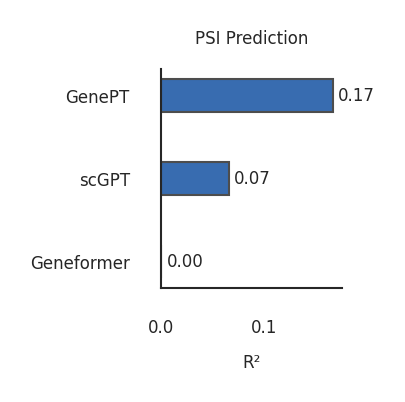

In [51]:
# =========================================================
# 6a plot) Regression performance: rho² bar chart
# =========================================================
plot_sources = ['geneformer', 'scGPT', 'genePT_v2_protein']
source_labels = {'genePT_v2_protein': 'GenePT', 'geneformer': 'Geneformer', 'scGPT': 'scGPT'}

# Pick the single best PC count (highest mean rho² across all sources)
pc_summary = (reg_results_df[reg_results_df['source'].isin(plot_sources)]
              .groupby('n_pcs')['rho2']
              .mean())
best_pc = pc_summary.idxmax()
print(f"Best PC count (avg rho² across all sources): {best_pc}")
print(pc_summary)

best_df = reg_results_df[(reg_results_df['source'].isin(plot_sources)) &
                          (reg_results_df['n_pcs'] == best_pc)]

sns.set_theme(style="white")

fig, ax = plt.subplots(figsize=(1.5,1.5), dpi=300)

sub = best_df.set_index('source').loc[plot_sources]
y_pos = np.arange(len(plot_sources))
bar_h = 0.4

ax.barh(y_pos, sub['rho2'], height=bar_h, color='#386cb0',
        edgecolor='0.3', linewidth=0.5)

for i, src in enumerate(plot_sources):
    val = sub.loc[src, 'rho2']
    ax.text(val + 0.005, i, f'{val:.2f}', va='center', fontsize=4)

ax.set_yticks(y_pos)
ax.set_yticklabels([source_labels[s] for s in plot_sources], fontsize=4)
# ax.set_xlim(0, 0.3)
ax.set_xlabel('R²', fontsize=4)
ax.set_title('PSI Prediction', fontsize=4)
ax.tick_params(axis='x', labelsize=4, direction='out', length=4, width=0.8)
ax.tick_params(axis='y', labelsize=4, direction='out', length=4, width=0.8)

sns.despine(ax=ax, top=True, right=True)
ax.spines['left'].set_linewidth(0.5)
ax.spines['bottom'].set_linewidth(0.5)

plt.tight_layout()
if save_plot:
    plt.savefig('Fig2/Fig2B_emb_regression_rho2.png', bbox_inches='tight', dpi=300)
    plt.savefig('Fig2/Fig2B_emb_regression_rho2.svg', bbox_inches='tight')
plt.show()


In [36]:
# =========================================================
# 6b) Classification: predict hammer/scalpel vs rest from gene embeddings
# =========================================================
# Scaler + PCA fit on train only (no look-ahead bias)
# Sweep over different numbers of PCs
from sklearn.metrics import average_precision_score

pc_grid = [10, 20, 50, 100, 200]
clf_results = []

for task_name, positive_set in [("HAMMER (bottom 25%) vs rest", hammers),
                                 ("SCALPEL (top 25%) vs rest", scalpels)]:
    print(f"\n{'='*105}")
    print(f"  {task_name}")
    print(f"{'='*105}")
    print(f"{'Source':>25s} | {'PCs':>3s} | {'n':>4s} | {'n_pos':>5s} | {'AUROC':>7s} | {'min':>5s} | {'max':>5s} | {'AUPRC':>7s} | {'min':>5s} | {'max':>5s}")
    print("-" * 105)

    for src_name, src in emb_sources.items():
        emb_array, emb2idx = load_and_normalize(src)

        perts_in = [p for p in avg_psi.index if p in emb2idx]
        if len(perts_in) < 30:
            print(f"{src_name:>25s} |     | {len(perts_in):>4d} | skipped (too few)")
            continue

        X_raw = np.array([emb_array[emb2idx[p]] for p in perts_in], dtype=np.float32)
        y = np.array([1 if p in positive_set else 0 for p in perts_in])
        max_comp = X_raw.shape[1]

        for n_comp in pc_grid:
            if n_comp > max_comp:
                continue

            auc_scores, auprc_scores = [], []
            for tr_idx, te_idx in skf.split(X_raw, y):
                scaler = StandardScaler().fit(X_raw[tr_idx])
                pca = PCA(n_components=n_comp, random_state=42).fit(scaler.transform(X_raw[tr_idx]))
                X_tr = pca.transform(scaler.transform(X_raw[tr_idx]))
                X_te = pca.transform(scaler.transform(X_raw[te_idx]))

                m = LogisticRegressionCV(Cs=10, cv=5, penalty='l2', max_iter=5000,
                                          random_state=42).fit(X_tr, y[tr_idx])
                probs = m.predict_proba(X_te)[:, 1]
                if len(np.unique(y[te_idx])) == 2:
                    auc_scores.append(roc_auc_score(y[te_idx], probs))
                    auprc_scores.append(average_precision_score(y[te_idx], probs))

            auc_mean = np.mean(auc_scores) if auc_scores else float('nan')
            auc_min = np.min(auc_scores) if auc_scores else float('nan')
            auc_max = np.max(auc_scores) if auc_scores else float('nan')
            auprc_mean = np.mean(auprc_scores) if auprc_scores else float('nan')
            auprc_min = np.min(auprc_scores) if auprc_scores else float('nan')
            auprc_max = np.max(auprc_scores) if auprc_scores else float('nan')
            n_pos = y.sum()

            clf_results.append({
                'task': task_name, 'source': src_name, 'n_pcs': n_comp,
                'n': len(perts_in), 'n_pos': n_pos,
                'auroc_mean': auc_mean, 'auroc_min': auc_min, 'auroc_max': auc_max,
                'auprc_mean': auprc_mean, 'auprc_min': auprc_min, 'auprc_max': auprc_max,
            })

            print(f"{src_name:>25s} | {n_comp:>3d} | {len(perts_in):>4d} | {n_pos:>5d} | {auc_mean:>7.4f} | {auc_min:>5.3f} | {auc_max:>5.3f} | {auprc_mean:>7.4f} | {auprc_min:>5.3f} | {auprc_max:>5.3f}")

        print()  # blank line between embeddings

    print(f"  (random baseline AUPRC = {len(positive_set)/len(avg_psi):.3f})")

clf_results_df = pd.DataFrame(clf_results)



  HAMMER (bottom 25%) vs rest
                   Source | PCs |    n | n_pos |   AUROC |   min |   max |   AUPRC |   min |   max
---------------------------------------------------------------------------------------------------------
                   genePT |  10 |  283 |    70 |  0.6665 | 0.597 | 0.806 |  0.4310 | 0.294 | 0.650
                   genePT |  20 |  283 |    70 |  0.6372 | 0.548 | 0.789 |  0.4018 | 0.274 | 0.654
                   genePT |  50 |  283 |    70 |  0.6048 | 0.505 | 0.769 |  0.3635 | 0.244 | 0.616
                   genePT | 100 |  283 |    70 |  0.6128 | 0.517 | 0.782 |  0.3756 | 0.273 | 0.646
                   genePT | 200 |  283 |    70 |  0.6182 | 0.507 | 0.779 |  0.3750 | 0.253 | 0.642

        genePT_v2_protein |  10 |  283 |    70 |  0.7237 | 0.573 | 0.870 |  0.5199 | 0.399 | 0.687
        genePT_v2_protein |  20 |  283 |    70 |  0.6952 | 0.595 | 0.791 |  0.4828 | 0.360 | 0.677
        genePT_v2_protein |  50 |  283 |    70 |  0.7053 | 0.591 | 0.8

In [38]:
clf_results_df.to_parquet("clf_results_df.parquet")

In [46]:
display_names = {'HAMMER (bottom 25%) vs rest': 'Sledgehammer', 'SCALPEL (top 25%) vs rest': 'Scalpel'}


Best PC count (avg AUROC across all sources/tasks): 10
n_pcs
10     0.599960
20     0.594657
50     0.598571
100    0.598081
200    0.597357
Name: auroc_mean, dtype: float64


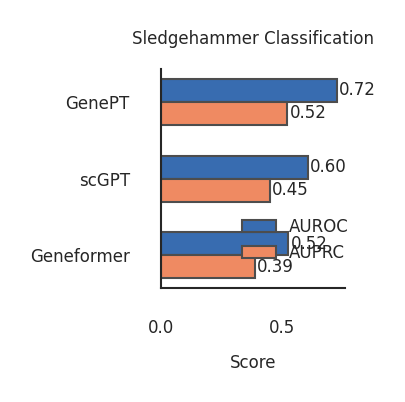

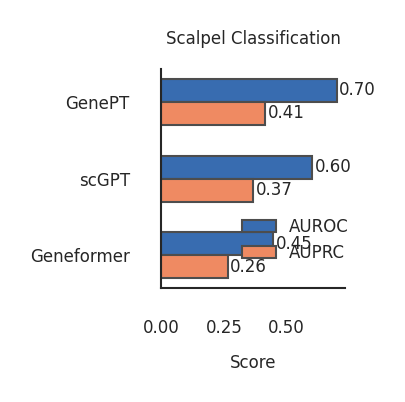

In [54]:
# =========================================================
# 6b plot) Classification performance: AUROC & AUPRC bar chart
# =========================================================
plot_sources = ['geneformer', 'scGPT', 'genePT_v2_protein']

source_labels = {'genePT_v2_protein': 'GenePT', 'geneformer': 'Geneformer', 'scGPT': 'scGPT'}
display_names = {'HAMMER (bottom 25%) vs rest': 'Sledgehammer Classification', 'SCALPEL (top 25%) vs rest': 'Scalpel Classification'}

# Pick the single best PC count (highest mean AUROC averaged across all sources and tasks)
pc_summary = (clf_results_df[clf_results_df['source'].isin(plot_sources)]
              .groupby('n_pcs')['auroc_mean']
              .mean())
best_pc = pc_summary.idxmax()
print(f"Best PC count (avg AUROC across all sources/tasks): {best_pc}")
print(pc_summary)

best_df = clf_results_df[(clf_results_df['source'].isin(plot_sources)) &
                          (clf_results_df['n_pcs'] == best_pc)]

sns.set_theme(style="white")

for task_name, _ in [("HAMMER (bottom 25%) vs rest", hammers),
                      ("SCALPEL (top 25%) vs rest", scalpels)]:
    fig, ax = plt.subplots(figsize=(1.5, 1.5), dpi=300)

    sub = best_df[best_df['task'] == task_name].set_index('source').loc[plot_sources]
    y_pos = np.arange(len(plot_sources))
    bar_h = 0.3

    ax.barh(y_pos + bar_h/2, sub['auroc_mean'], height=bar_h, color='#386cb0',
            edgecolor='0.3', linewidth=0.5, label='AUROC')
    ax.barh(y_pos - bar_h/2, sub['auprc_mean'], height=bar_h, color='#ef8a62',
            edgecolor='0.3', linewidth=0.5, label='AUPRC')

    for i, src in enumerate(plot_sources):
        row = sub.loc[src]
        ax.text(row['auroc_mean'] + 0.01, i + bar_h/2, f'{row["auroc_mean"]:.2f}', va='center', fontsize=4)
        ax.text(row['auprc_mean'] + 0.01, i - bar_h/2, f'{row["auprc_mean"]:.2f}', va='center', fontsize=4)


    ax.set_yticks(y_pos)
    ax.set_yticklabels([source_labels[s] for s in plot_sources], fontsize=4)
    ax.set_xlabel('Score', fontsize=4)
    ax.set_title(display_names[task_name], fontsize=4)
    ax.tick_params(axis='x', labelsize=4, direction='out', length=4, width=0.8)
    ax.tick_params(axis='y', labelsize=4, direction='out', length=4, width=0.8)
    ax.legend(fontsize=4, loc='lower right', bbox_to_anchor=(1.1, 0.05), frameon=False)

    sns.despine(ax=ax, top=True, right=True)
    ax.spines['left'].set_linewidth(0.5)
    ax.spines['bottom'].set_linewidth(0.5)

    plt.tight_layout()
    tag = 'sledgehammer' if 'HAMMER' in task_name else 'scalpel'
    if save_plot:
        plt.savefig(f'Fig2/Fig2B_emb_classification_{tag}.png', bbox_inches='tight', dpi=300)
        plt.savefig(f'Fig2/Fig2B_emb_classification_{tag}.svg', bbox_inches='tight')
    plt.show()
